In [ ]:
'''
import duckdb

# Connect to DuckDB warehouse
con = duckdb.connect("C:/Users/aliso/data-analytics-demo/warehouse/dev.duckdb")

# List all tables
print(con.execute("SHOW TABLES").fetchdf())

# Check row counts in staging
print("stg_orders_seed rows:", con.execute("SELECT COUNT(*) FROM stg_orders_seed").fetchone())

# Check row counts in marts
print("fct_orders rows:", con.execute("SELECT COUNT(*) FROM fct_orders").fetchone())
print("dim_customers rows:", con.execute("SELECT COUNT(*) FROM dim_customers").fetchone())
'''

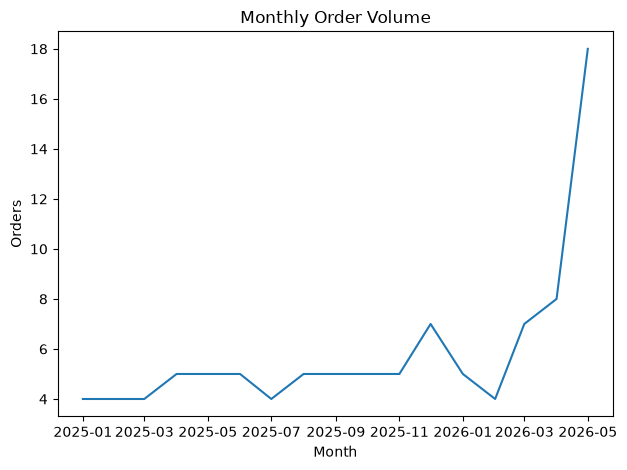

In [1]:
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect("C:/Users/aliso/data-analytics-demo/warehouse/dev.duckdb")

arr_mrr_df = con.execute("""
    SELECT CAST(DATE_TRUNC('month', order_date) AS DATE) AS month,
           COUNT(order_id) AS order_count
    FROM fct_orders
    GROUP BY month
    ORDER BY month
""").df()

sns.lineplot(data=arr_mrr_df, x="month", y="order_count")
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()